In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
data =pd.read_csv("data/loan_approval_data.csv")
data

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [5]:
#Handle missing values
categorical_cols=data.select_dtypes(include=["object"]).columns
numerical_cols=data.select_dtypes(include=["number"]).columns



In [6]:
from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy="mean")
data[numerical_cols]=num_imp.fit_transform(data[numerical_cols])


In [7]:
cat_imp=SimpleImputer(strategy="most_frequent")
data[categorical_cols]=cat_imp.fit_transform(data[categorical_cols])



EDA

Text(0.5, 1.0, 'Is Loan Approved or Not')

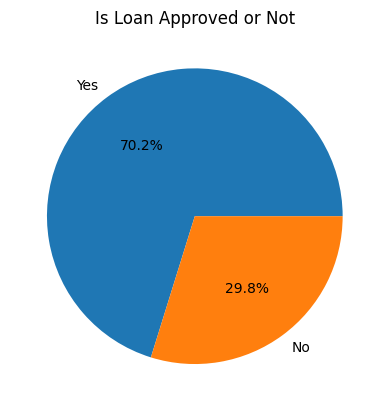

In [8]:
classes_count=data["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["Yes","No"],autopct="%1.1f%%")
plt.title("Is Loan Approved or Not")


[Text(0, 0, '621'), Text(0, 0, '379')]

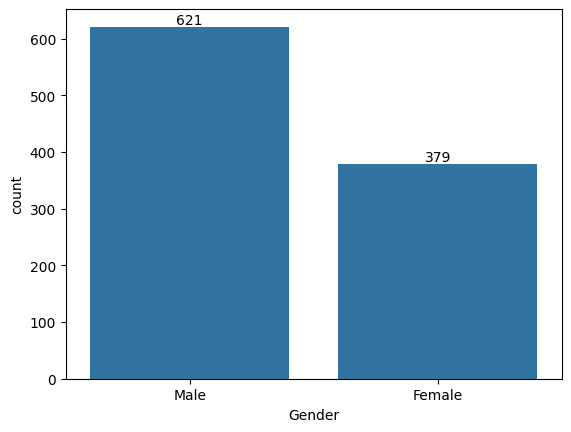

In [9]:
gender_count=data["Gender"].value_counts()
ax=sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

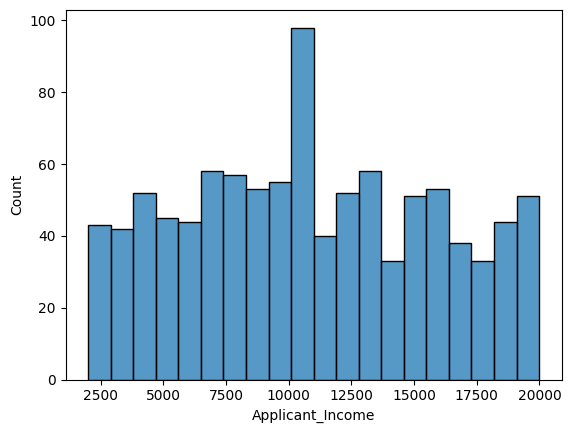

In [10]:
sns.histplot(
    data=data,
    x="Applicant_Income",
    bins=20
    
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

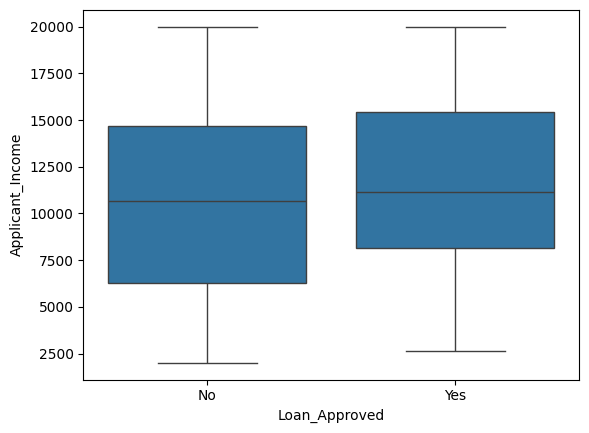

In [11]:
#outliers-box plots
sns.boxplot(
    data=data,
    x="Loan_Approved",
    y="Applicant_Income"
)

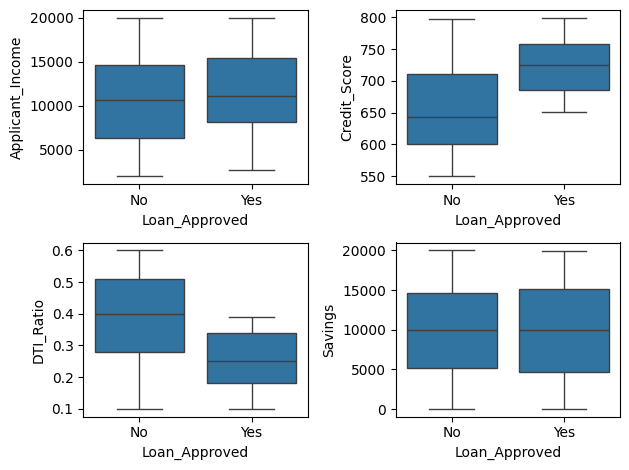

In [12]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=data,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=data,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=data,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=data,x="Loan_Approved",y="Savings")
plt.tight_layout()

In [13]:
 data=data.drop(columns=["Applicant_ID"])


Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le=LabelEncoder()
data["Education_Level"]=le.fit_transform(data["Education_Level"])
data["Loan_Approved"]=le.fit_transform(data["Loan_Approved"])



In [15]:
cols=["Employment_Status","Marital_Status","Property_Area","Gender","Employer_Category","Loan_Purpose"]
ohe=OneHotEncoder(drop="first",sparse_output=False , handle_unknown="ignore")
encoded=ohe.fit_transform(data[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=data.index)
data=pd.concat([data.drop(columns=cols),encoded_df],axis=1)


In [16]:
data

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


Correlation Heatmap

In [17]:
nums_cols=data.select_dtypes(include="number")
corr_matrix=nums_cols.corr()
nums_cols.corr()["Loan_Approved"].sort_values(ascending=False)


Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

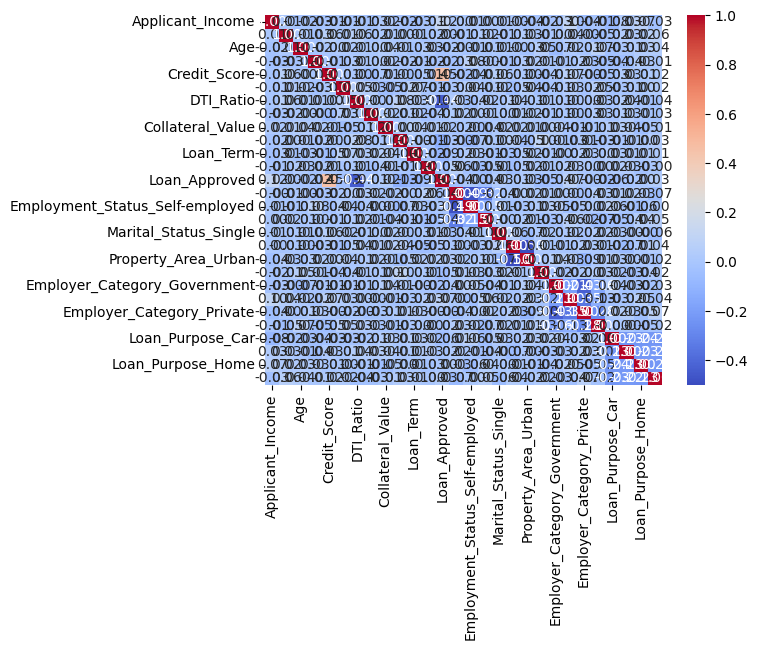

In [18]:
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
    
    
)

In [19]:
X=data.drop("Loan_Approved",axis=1)


Y=data["Loan_Approved"]

In [20]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)


In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


Train and Evaluate model

In [22]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train_scaled,Y_train)
y_predict=model.predict(X_test_scaled)


In [23]:
from sklearn.metrics import precision_score,recall_score,accuracy_score,confusion_matrix

print("Precison :",precision_score(Y_test,y_predict) )
print("Accuracy :",accuracy_score(Y_test,y_predict) )
print("Recall :",recall_score(Y_test,y_predict) )
print("CM :",confusion_matrix(Y_test,y_predict) )


Precison : 0.7833333333333333
Accuracy : 0.865
Recall : 0.7704918032786885
CM : [[126  13]
 [ 14  47]]


Feature Engineering

In [24]:
data["DTI_Ratio_sq"]=data["DTI_Ratio"] **2
data["Credit_Score_sq"]=data["Credit_Score"] **2

# data["Applicant_Income_log"]=np.log1p(data["Applicant_Income"])
X=data.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
Y=data["Loan_Approved"]

In [25]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(X_train_scaled,Y_train)
y_predict=model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,accuracy_score,confusion_matrix

print("Precison :",precision_score(Y_test,y_predict) )
print("Accuracy :",accuracy_score(Y_test,y_predict) )
print("Recall :",recall_score(Y_test,y_predict) )
print("CM :",confusion_matrix(Y_test,y_predict) )


Precison : 0.7833333333333333
Accuracy : 0.865
Recall : 0.7704918032786885
CM : [[126  13]
 [ 14  47]]
